<a href="https://colab.research.google.com/github/pxtroniwnl/f1-pole-predictor/blob/main/f1_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🏎️ F1 Predictor: Machine Learning para la Pole Position y Resultados de Carrera
### Análisis de Telemetría y Modelado Predictivo en la Fórmula 1

![F1 Data Science](https://img.shields.io/badge/Status-In%20Development-green?style=for-the-badge&logo=python)
![Framework](https://img.shields.io/badge/Framework-FastF1%20%7C%20Scikit--Learn-blue?style=for-the-badge)

---

## 📋 Descripción del Proyecto
Este proyecto tiene como objetivo desarrollar un sistema de inteligencia artificial capaz de predecir resultados clave en un fin de semana de Gran Premio (GP). A diferencia de las predicciones basadas puramente en azar, este modelo utiliza **datos históricos y telemetría en tiempo real** para identificar patrones de rendimiento que definen el éxito en la pista.

### Objetivos Principales:
1.  **Predicción de la Pole Position:** Identificar al piloto que obtendrá el mejor tiempo en la sesión de clasificación (Q3) analizando el ritmo de las vueltas rápidas.
2.  **Pronóstico de Carrera:** Predecir las posiciones finales y el ganador del domingo basándose en la degradación de neumáticos, ritmo de tanda larga y variables del constructor.

Todo esto para la GP de Japon del 29 de marzo
---

## 🛠️ Stack Tecnológico
* **Lenguaje:** Python (Jupyter Notebook)
* **Fuentes de Datos:** `FastF1 API` (Telemetría y tiempos), `Ergast API` (Datos históricos).
* **Librerías de Análisis:** `Pandas`, `Numpy`, `Matplotlib`, `Seaborn`.
* **Machine Learning:** `XGBoost` / `LightGBM` (Modelos de Gradient Boosting para datos tabulares).
* **Optimización:** Implementación de **Cache local** para el manejo eficiente de grandes volúmenes de datos de telemetría.

---

In [1]:
!pip install fastf1

In [2]:
import fastf1
from fastf1 import plotting
from matplotlib import pyplot as plt
import os

# Habilitar el cache en una carpeta local
cache_dir = 'cache_f1'
os.makedirs(cache_dir, exist_ok=True)
fastf1.Cache.enable_cache(cache_dir)

# Configurar el estilo visual de FastF1 para gráficos
plotting.setup_mpl()

# ¿Como obtengo esas predicciones?

Bueno lo primero es definir los datos a obtener:

Por un lado tenemos los de ***Rendimiento***

- Los tiempos **por sector** es algo crucial, en Japon, el Sector 1 es de curvas entrelazadas, el 2 es Tecnico y el 3 de pura velocidad, es decir, un ejemplo si tenemos un coche rapido en el S1 pero lento en el S3 eso podria decirnos que tiene muchisima carga pero poca eficiencia

- El **Laptime** y **Personal Best** para comparar la consistencia del piloto

- La **Speed Trap** es la Velocidad Maxima Alcanzada, esto indica si el motor es Honda o Mercedes esta dando toda la potencia

Por otro lado tenemos los de ***Telemetria*** o ***ADN del coche***

- Throttle (Acelerador): ¿Qué porcentaje de la vuelta van a fondo?

- Brake (Freno): ¿Qué tan agresivo es el frenado en la chicana de entrada a meta?

- nGear (Marchas): Cuántos cambios hacen. Esto indica la elasticidad del motor.

Por ultimo tenemos los del ***Contexto***

- Histórico de Suzuka: Datos de los últimos 3 a 5 años (2021-2025). Esto ayuda al modelo a entender el "carácter" del circuito.

- Temporada Actual: Datos de las 3 carreras anteriores al GP de Japón de este año. Esto le dice al modelo qué equipo (Red Bull, Ferrari, McLaren) llega con el mejor desarrollo técnico ahora.

- Sesiones del fin de semana: Datos de FP1, FP2 y FP3. Las simulaciones de carrera en FP2 son el mejor predictor para el domingo.

## Extraccion de A, B & C

Aquii extraemos los Pilares A, B Y C mencionados anteiormente pero con un bucle for para cada año de competicion

1. Transformación a Milisegundos: Los modelos de ML (XGBoost) no entienden objetos de tiempo (Timedelta). Por eso convertimos los Sectores y el LapTime a milisegundos (float).

2. Agregación de Telemetría: En lugar de darle al modelo 500 puntos de velocidad, le dimos la Velocidad Promedio y el % de tiempo con acelerador a fondo. Esto es mucho más "digerible" para un algoritmo.

3. Contexto Climático: Añadimos la temperatura de la pista. En Suzuka, si la pista sube 5°C, el Sector 1 se vuelve mucho más lento por el sobrecalentamiento de las gomas.

In [3]:
import fastf1
import pandas as pd
import time

años = [2022, 2023, 2024]
dataset_historico = []

for anio in años:
    try:
        # Cargamos la sesión de Clasificación (Q)
        session = fastf1.get_session(anio, 'Japan', 'Q')
        session.load()

        # Datos meteorológicos promedio de la sesión
        weather = session.weather_data.mean(numeric_only=True)

        for driver in session.drivers:
            laps_driver = session.laps.pick_driver(driver)
            best_lap = laps_driver.pick_fastest()

            # Validar que el piloto haya marcado tiempo
            if best_lap is None or pd.isna(best_lap['LapTime']):
                continue

            # Extracción de Telemetría Agregada (Pilar B)
            tel = best_lap.get_telemetry()

            fila = {
                'Year': anio,
                'Driver': driver,
                'Team': best_lap['Team'],
                # Pilar A: Rendimiento
                'LapTime_ms': best_lap['LapTime'].total_seconds() * 1000,
                'S1_ms': best_lap['Sector1Time'].total_seconds() * 1000,
                'S2_ms': best_lap['Sector2Time'].total_seconds() * 1000,
                'S3_ms': best_lap['Sector3Time'].total_seconds() * 1000,
                'SpeedTrap': best_lap['SpeedST'],
                # Pilar B: Telemetría
                'MaxSpeed': tel['Speed'].max(),
                'AvgSpeed': tel['Speed'].mean(),
                'ThrottleFullPct': (tel['Throttle'] > 95).mean(),
                'BrakeHardPct': (tel['Brake'] > 50).mean(),
                # Pilar C: Contexto
                'Compound': best_lap['Compound'],
                'TyreLife': best_lap['TyreLife'],
                'AirTemp': weather['AirTemp'],
                'TrackTemp': weather['TrackTemp']
            }
            dataset_historico.append(fila)

    except Exception as e:
        print(f"Error en el año {anio}: {e}")

# 2. Guardar a CSV
df_suzuka = pd.DataFrame(dataset_historico)
df_suzuka.to_csv('datos_f1_suzuka_historico.csv', index=False)
print("\n¡Listo! Archivo 'datos_f1_suzuka_historico.csv' creado con éxito.")

core           INFO 	Loading data for Japanese Grand Prix - Qualifying [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Japanese Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing timing data...
INFO:fastf1.fastf1.core:Processing timing data...
req       


¡Listo! Archivo 'datos_f1_suzuka_historico.csv' creado con éxito.


In [4]:
df_suzuka

,Year,Driver,Team,LapTime_ms,S1_ms,S2_ms,S3_ms,SpeedTrap,MaxSpeed,AvgSpeed,ThrottleFullPct,BrakeHardPct,Compound,TyreLife,AirTemp,TrackTemp
0,2022,1,Red Bull Racing,89304.0,31116.0,40406.0,17782.0,303.0,331.0,234.249858,0.637329,0.0,SOFT,2.0,19.896104,26.497403
1,2022,16,Ferrari,89314.0,31149.0,40166.0,17999.0,300.0,326.0,233.064305,0.668116,0.0,SOFT,2.0,19.896104,26.497403
2,2022,55,Ferrari,89361.0,31127.0,40275.0,17959.0,302.0,329.0,231.724542,0.636494,0.0,SOFT,2.0,19.896104,26.497403
3,2022,11,Red Bull Racing,89709.0,31373.0,40433.0,17903.0,301.0,331.0,232.634876,0.643994,0.0,SOFT,2.0,19.896104,26.497403
4,2022,31,Alpine,90165.0,31333.0,40786.0,18046.0,300.0,326.0,231.374318,0.633478,0.0,SOFT,2.0,19.896104,26.497403
5,2022,44,Mercedes,90261.0,31321.0,40766.0,18174.0,292.0,321.0,230.716181,0.650862,0.0,SOFT,2.0,19.896104,26.497403
6,2022,14,Alpine,90322.0,31455.0,40707.0,18160.0,301.0,326.0,228.563532,0.616766,0.0,SOFT,2.0,19.896104,26.497403
7,2022,63,Mercedes,90389.0,31474.0,40730.0,18185.0,292.0,321.0,230.911114,0.637536,0.0,SOFT,2.0,19.896104,26.497403
8,2022,5,Aston Martin,90554.0,31655.0,40741.0,18158.0,295.0,318.0,228.676964,0.616930,0.0,SOFT,2.0,19.896104,26.497403
9,2022,4,McLaren,90473.0,31427.0,41017.0,18029.0,297.0,323.0,228.828217,0.622255,0.0,SOFT,2.0,19.896104,26.497403


# Limpieza y Escalado

In [5]:
from sklearn.preprocessing import StandardScaler

df_list = []
for anio in df_suzuka['Year'].unique():
    df_anio = df_suzuka[df_suzuka['Year'] == anio].copy()

    features = ['S1_ms', 'S2_ms', 'S3_ms', 'SpeedTrap', 'MaxSpeed',
            'AvgSpeed', 'ThrottleFullPct', 'BrakeHardPct', 'TrackTemp']

    scaler_anio = StandardScaler()
    df_anio[features] = scaler_anio.fit_transform(df_anio[features])

    df_list.append(df_anio)

df_final_escalado = pd.concat(df_list)

In [6]:
df_final_escalado

,Year,Driver,Team,LapTime_ms,S1_ms,S2_ms,S3_ms,SpeedTrap,MaxSpeed,AvgSpeed,ThrottleFullPct,BrakeHardPct,Compound,TyreLife,AirTemp,TrackTemp
0,2022,1,Red Bull Racing,89304.0,-1.537228,-1.364407,-2.388583,1.086185,1.433585,2.000341,0.545186,0.0,SOFT,2.0,19.896104,3.552714e-15
1,2022,16,Ferrari,89314.0,-1.431256,-2.111089,-0.809294,0.370019,0.186989,1.494139,1.548268,0.0,SOFT,2.0,19.896104,3.552714e-15
2,2022,55,Ferrari,89361.0,-1.501904,-1.771971,-1.100408,0.847463,0.934947,0.922093,0.517979,0.0,SOFT,2.0,19.896104,3.552714e-15
3,2022,11,Red Bull Racing,89709.0,-0.711935,-1.280405,-1.507966,0.608741,1.433585,1.310783,0.762341,0.0,SOFT,2.0,19.896104,3.552714e-15
4,2022,31,Alpine,90165.0,-0.840385,-0.182159,-0.467237,0.370019,0.186989,0.772556,0.419693,0.0,SOFT,2.0,19.896104,3.552714e-15
5,2022,44,Mercedes,90261.0,-0.878920,-0.244383,0.464325,-1.539757,-1.059607,0.491547,0.986107,0.0,SOFT,2.0,19.896104,3.552714e-15
6,2022,14,Alpine,90322.0,-0.448612,-0.427942,0.362436,0.608741,0.186989,-0.427581,-0.124786,0.0,SOFT,2.0,19.896104,3.552714e-15
7,2022,63,Mercedes,90389.0,-0.387598,-0.356385,0.544382,-1.539757,-1.059607,0.574779,0.551915,0.0,SOFT,2.0,19.896104,3.552714e-15
8,2022,5,Aston Martin,90554.0,0.193639,-0.322162,0.347880,-0.823591,-1.807564,-0.379148,-0.119467,0.0,SOFT,2.0,19.896104,3.552714e-15
9,2022,4,McLaren,90473.0,-0.538527,0.536522,-0.590960,-0.346147,-0.560968,-0.314567,0.054032,0.0,SOFT,2.0,19.896104,3.552714e-15


In [8]:
df_final_escalado.describe()

,Year,LapTime_ms,S1_ms,S2_ms,S3_ms,SpeedTrap,MaxSpeed,AvgSpeed,ThrottleFullPct,BrakeHardPct,TyreLife,AirTemp,TrackTemp
count,59.000000,59.00000,5.900000e+01,5.900000e+01,5.900000e+01,5.900000e+01,5.900000e+01,5.900000e+01,5.900000e+01,59.0,59.0,59.000000,5.900000e+01
mean,2023.000000,90033.79661,-2.408619e-15,1.072588e-16,-5.208640e-15,2.039800e-15,-3.752177e-15,-6.441175e-15,-1.220304e-15,0.0,2.0,21.090911,3.492498e-15
std,0.830455,875.60491,1.008584e+00,1.008584e+00,1.008584e+00,1.008584e+00,1.008584e+00,1.008584e+00,1.008584e+00,0.0,0.0,3.608071,2.912622e-15
min,2022.000000,88197.00000,-2.324246e+00,-2.111089e+00,-2.388583e+00,-1.539757e+00,-1.807564e+00,-2.145300e+00,-2.448250e+00,0.0,2.0,17.539474,0.000000e+00
25%,2022.000000,89465.00000,-8.465782e-01,-7.299763e-01,-6.717227e-01,-7.276069e-01,-8.501248e-01,-8.040630e-01,-5.163777e-01,0.0,2.0,17.539474,0.000000e+00
50%,2023.000000,90139.00000,1.618866e-01,-1.228977e-02,-2.537410e-02,-2.425356e-01,-6.232980e-02,4.149007e-02,1.995254e-01,0.0,2.0,19.896104,3.552714e-15
75%,2024.000000,90622.50000,6.695726e-01,8.208707e-01,6.053464e-01,6.087410e-01,7.107791e-01,7.371474e-01,6.142125e-01,0.0,2.0,26.086957,7.105427e-15
max,2024.000000,91511.00000,2.300222e+00,1.852322e+00,2.615425e+00,2.182821e+00,2.269134e+00,2.000341e+00,1.753983e+00,0.0,2.0,26.086957,7.105427e-15


In [14]:
pole_times = df_final_escalado.groupby('Year')['LapTime_ms'].transform('min')

In [15]:
pole_times

,LapTime_ms
0,89304.0
1,89304.0
2,89304.0
3,89304.0
4,89304.0
5,89304.0
6,89304.0
7,89304.0
8,89304.0
9,89304.0


In [16]:
df_final_escalado['Gap_to_Pole'] = df_final_escalado['LapTime_ms'] - pole_times

In [17]:
df_final_escalado[['Year', 'Driver', 'LapTime_ms', 'Gap_to_Pole']].head()

,Year,Driver,LapTime_ms,Gap_to_Pole
0,2022,1,89304.0,0.0
1,2022,16,89314.0,10.0
2,2022,55,89361.0,57.0
3,2022,11,89709.0,405.0
4,2022,31,90165.0,861.0


# Modelo A (Histórico)

In [25]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

features_escaladas = ['S1_ms', 'S2_ms', 'S3_ms', 'SpeedTrap', 'MaxSpeed',
                      'AvgSpeed', 'ThrottleFullPct', 'BrakeHardPct']

X = df_final_escalado[features_escaladas]
y = df_final_escalado['Gap_to_Pole']

# Dividimos: entrenamos con 80% y probamos con 20%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Configuración del modelo
modelo_f1 = xgb.XGBRegressor(
    n_estimators=500,    # Cuántos árboles construir
    learning_rate=0.05,  # Paso pequeño para mayor precisión
    max_depth=4,         # Profundidad moderada para no sobreajustar
    subsample=0.8,       # Usar solo el 80% de datos por árbol para generalizar
    colsample_bytree=0.8
)

# Entrenamos
modelo_f1.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

# Evaluemos...

In [20]:
preds = modelo_f1.predict(X_test)
error = mean_absolute_error(y_test, preds)
print(f"Error promedio del modelo: {error:.2f} ms")

Error promedio del modelo: 237.87 ms


# Veamos importancia de Features

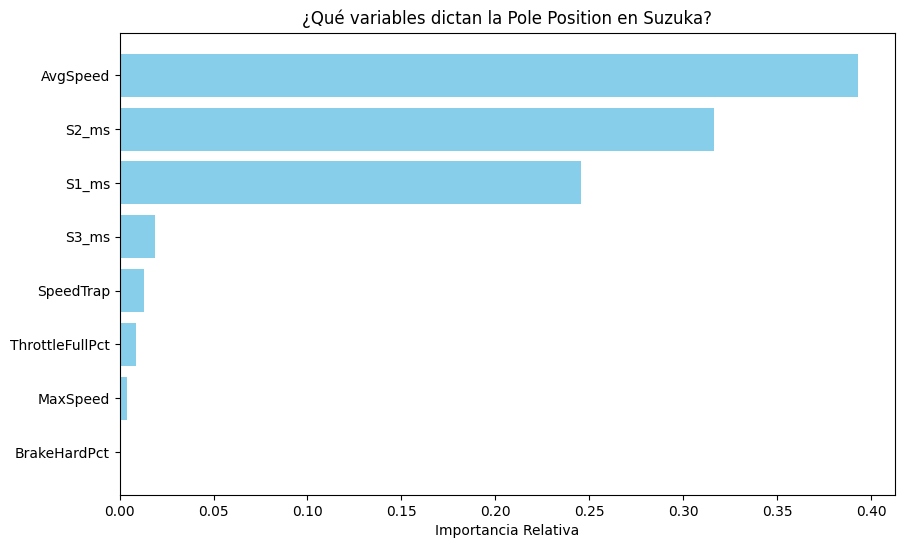

In [22]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Obtener la importancia de las características
importancias = modelo_f1.feature_importances_
feature_names = X.columns

# 2. Crear un DataFrame para visualizarlo mejor
df_importancia = pd.DataFrame({'Feature': feature_names, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# 3. Graficar
plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Feature'], df_importancia['Importancia'], color='skyblue')
plt.xlabel('Importancia Relativa')
plt.title('¿Qué variables dictan la Pole Position en Suzuka?')
plt.gca().invert_yaxis()
plt.show()

# Optimicemos aun mas para un mejor modelo

In [23]:
from sklearn.model_selection import GridSearchCV

# Definimos el espacio de búsqueda
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Configuramos la búsqueda
grid_search = GridSearchCV(
    estimator=xgb.XGBRegressor(objective='reg:squarederror'),
    param_grid=param_grid,
    cv=3, # Validación cruzada de 3 pliegues
    scoring='neg_mean_absolute_error',
    verbose=1,
    n_jobs=-1 # Usa todos tus núcleos de procesador
)

# Ejecutamos la búsqueda con tus datos escalados
grid_search.fit(X_train, y_train)

print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Mejor MAE en entrenamiento: {-grid_search.best_score_:.2f} ms")

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Mejores parámetros: {'colsample_bytree': 0.9, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 100, 'subsample': 0.8}
Mejor MAE en entrenamiento: 155.10 ms


# Modelo B (Temporada 2026)

In [24]:
import fastf1
import pandas as pd


carreras_2026 = [1, 2, 3]
datos_temporada = []

for round_num in carreras_2026:
    session = fastf1.get_session(2026, round_num, 'Q')
    session.load()

    for driver in session.drivers:
        lap = session.laps.pick_driver(driver).pick_fastest()
        if lap is not None:
            datos_temporada.append({
                'Driver': driver,
                'Team': lap['Team'],
                'Position': lap['Position'],
                'Gap_to_Pole': lap['LapTime'].total_seconds() - session.laps.pick_fastest()['LapTime'].total_seconds()
            })

df_2026 = pd.DataFrame(datos_temporada)
# 2. Calcular el promedio de forma actual
forma_actual = df_2026.groupby('Driver')['Gap_to_Pole'].mean().sort_values()
print("Ranking de Probabilidad (basado en la temporada 2026):")
print(forma_actual)

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Australian Grand Prix - Qualifying [v3.8.1]
req            INFO 	No cached data found for session_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...
INFO:fastf1.api:Fetching session info data...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
INFO:fastf1.fastf1.req:No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
INFO:fastf1.api:Fetching driver list...
req            INFO 	Data has been written to cache!
INFO:fastf1.fastf1.req:Data has been written to cache!
DEBUG:fastf1.ergast:Failed to parse timestamp '' in Ergastresponse.
req            INFO 	No cached data found for session_status_

Ranking de Probabilidad (basado en la temporada 2026):
Driver
63    0.1110
12    0.1465
16    0.5865
44    0.6555
81    0.6740
1     0.7505
6     0.9210
3     0.9380
10    1.3960
87    1.4630
27    1.5375
41    1.5865
30    1.5885
5     1.5940
31    1.7235
43    1.9875
55    2.2530
23    2.5655
14    3.2950
18    3.9310
77    4.0490
11    4.4645
Name: Gap_to_Pole, dtype: float64


In [26]:
# Definimos las rondas que ya pasaron en 2026
rondas_2026 = [1, 2, 3] # Bahréin, Arabia, Australia
datos_temporada_actual = []

for r in rondas_2026:
    try:
        # Cargamos la clasificación de cada ronda
        s = fastf1.get_session(2026, r, 'Q')
        s.load()

        pole_time = s.laps.pick_fastest()['LapTime'].total_seconds()

        for drv in s.drivers:
            best_lap = s.laps.pick_driver(drv).pick_fastest()
            if best_lap is not None:
                datos_temporada_actual.append({
                    'Driver': drv,
                    'Team': best_lap['Team'],
                    'Round': r,
                    'QualyPos': best_lap['Position'],
                    'Gap_to_Pole_Sec': best_lap['LapTime'].total_seconds() - pole_time
                })
    except Exception as e:
        print(f"Error cargando ronda {r}: {e}")

df_2026 = pd.DataFrame(datos_temporada_actual)

# Agrupamos por piloto para obtener su "Estado de Forma"
forma_pilotos = df_2026.groupby('Driver').agg({
    'QualyPos': 'mean',
    'Gap_to_Pole_Sec': 'mean'
}).reset_index()

print(forma_pilotos.sort_values(by='Gap_to_Pole_Sec'))

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]
INFO:fastf1.fastf1.core:Loading data for Australian Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
INFO:fastf1.fastf1.req:Using cached data for session_info
req            INFO 	Using cached data for driver_info
INFO:fastf1.fastf1.req:Using cached data for driver_info
DEBUG:fastf1.ergast:Failed to parse timestamp '' in Ergastresponse.
req            INFO 	Using cached data for session_status_data
INFO:fastf1.fastf1.req:Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
INFO:fastf1.fastf1.req:Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
INFO:fastf1.fastf1.req:Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
INFO:fastf1.fastf1.req:Using cached data for timing_app_data
core           INFO 	Processing tim

Error cargando ronda 3: The data you are trying to access has not been loaded yet. See `Session.load`
   Driver  QualyPos  Gap_to_Pole_Sec
18     63       NaN           0.1110
3      12       NaN           0.1465
5      16       NaN           0.5865
14     44       NaN           0.6555
20     81       NaN           0.6740
0       1       NaN           0.7505
17      6       NaN           0.9210
9       3       NaN           0.9380
1      10       NaN           1.3960
21     87       NaN           1.4630
8      27       NaN           1.5375
12     41       NaN           1.5865
10     30       NaN           1.5885
15      5       NaN           1.5940
11     31       NaN           1.7235
13     43       NaN           1.9875
16     55       NaN           2.2530
7      23       NaN           2.5655
4      14       NaN           3.2950
6      18       NaN           3.9310
19     77       NaN           4.0490
2      11       NaN           4.4645


# Modelo Ensemble (A+B)

- Modelo A (XGBoost de Telemetría): Sabe quién es el "Rey de Suzuka" (quién optimiza mejor el Sector 1 y la velocidad promedio en las eses).

- Modelo B: Sabe quién tiene el coche más rápido en este momento de la temporada.

In [41]:
import pandas as pd
historical_team_gap = df_final_escalado.groupby('Team')['Gap_to_Pole'].mean().reset_index()
historical_team_gap['Hist_Gap_Suzuka_Sec'] = historical_team_gap['Gap_to_Pole'] / 1000
historical_team_gap = historical_team_gap[['Team', 'Hist_Gap_Suzuka_Sec']]

prediccion_ensemble = pd.merge(forma_pilotos, historical_team_gap, on='Team', how='left')

overall_avg_hist_gap_sec = (df_final_escalado['Gap_to_Pole'].mean()) / 1000
prediccion_ensemble['Hist_Gap_Suzuka_Sec'] = prediccion_ensemble['Hist_Gap_Suzuka_Sec'].fillna(overall_avg_hist_gap_sec)

prediccion_ensemble['Final_Predicted_Gap'] = (
    (prediccion_ensemble['Gap_to_Pole_Sec'] * 0.6) +
    (prediccion_ensemble['Hist_Gap_Suzuka_Sec'] * 0.4)
)

# 6. Display results
ranking_ensemble = prediccion_ensemble[['Driver', 'Team', 'Final_Predicted_Gap']].sort_values(by='Final_Predicted_Gap').reset_index(drop=True)

print("--- PREDICCIÓN ENSEMBLE GP DE JAPÓN (Modelos A y B) ---")
print(ranking_ensemble.head(10))

--- PREDICCIÓN ENSEMBLE GP DE JAPÓN (Modelos A y B) ---
  Driver             Team  Final_Predicted_Gap
0     63         Mercedes             0.452933
1     12         Mercedes             0.474233
2     16          Ferrari             0.537167
3     44          Ferrari             0.578567
4      6  Red Bull Racing             0.635533
5      3  Red Bull Racing             0.645733
6     81          McLaren             0.709467
7      1          McLaren             0.755367
8     27             Audi             1.419524
9     10           Alpine             1.421333
